# Mini-Projet

Deux étapes principales :
- Une analyse et prédiction des données de test à partir d'un modèle de régression.
- Une classification des données d'apprentissage en plusieurs groupes, suivie d'une modélisation spécifique pour chaque groupe.

Les données d'apprentissage sont stockées dans `donapp.csv` et les données de test dans `dontest.csv`.

## Import des données

In [1]:
import pandas as pd
import os

# On cherche d'abord les fichiers dans le sous-répertoire "data". Si les fichiers ne sont pas trouvés, il les cherche dans le répertoire courant.

# Définir le chemin des fichiers
data_path = 'data'
file_donapp = 'donapp.csv'
file_dontest = 'dontest.csv'

# Fonction pour charger les fichiers
def load_data(file_name):
    file_path = os.path.join(data_path, file_name)
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        return pd.read_csv(file_name)

# Charger les jeux de données
donapp = load_data(file_donapp)
dontest = load_data(file_dontest)

# Afficher les premières lignes pour vérification
print(donapp.head())
print(dontest.head())




   Pitch_angle  Pitch_angle_std  Hub_temperature  Hub_temperature_std  \
0    92.410004              0.0             8.24                 0.28   
1    92.410004              0.0             6.83                 0.49   
2    92.410004              0.0             2.00                 0.00   
3    92.410004              0.0             3.96                 0.44   
4    92.410004              0.0             4.00                 0.00   

   Generator_converter_speed  Generator_converter_speed_std  Generator_speed  \
0                       3.92                           0.01             0.17   
1                       3.93                           0.38             0.17   
2                       4.26                           0.02             0.00   
3                       4.09                           0.01             0.06   
4                       4.46                           0.02             0.43   

   Generator_speed_std  Generator_bearing_1_temperature  \
0                 0.8

## Analyse exploratoire des données

Nous commençons par explorer les données pour mieux comprendre les caractéristiques.

In [2]:
# Afficher les premières lignes donapp
donapp.head()

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
0,92.410004,0.0,8.24,0.28,3.92,0.01,0.17,0.80,7.70,0.01,...,49.980000,0.01,0.0,0.0,2.38,0.06,302.899990,-0.853187,0.521605,-2.727
1,92.410004,0.0,6.83,0.49,3.93,0.38,0.17,1.89,7.70,0.00,...,0.000000,22.26,0.0,0.0,2.32,0.03,302.899990,-0.836286,0.548293,0.100
2,92.410004,0.0,2.00,0.00,4.26,0.02,0.00,0.05,-1.69,0.10,...,50.000000,0.01,0.0,0.0,-2.10,0.07,301.810000,0.995193,0.097930,-4.993
3,92.410004,0.0,3.96,0.44,4.09,0.01,0.06,0.34,-0.23,0.05,...,49.959999,0.01,0.0,0.0,-2.08,0.04,79.000000,0.973698,0.227841,-4.542
4,92.410004,0.0,4.00,0.00,4.46,0.02,0.43,0.36,0.75,0.03,...,49.990002,0.01,0.0,0.0,-2.02,0.03,69.120003,0.859585,0.510993,-3.145


In [3]:
donapp.describe()

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
count,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,...,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000,20423.000000
mean,11.827245,0.966495,19.963960,0.088400,1092.020753,62.578941,1092.631547,62.788820,39.810544,0.401748,...,49.974002,0.018661,10.387831,0.599220,31.244530,0.055423,178.807564,-0.100404,-0.104536,385.929542
std,26.054090,4.313085,6.827110,0.145344,590.726621,78.597941,591.885414,78.623959,7.848546,0.305192,...,1.067798,0.418653,5.638842,0.748875,7.181041,0.041361,96.302313,0.711867,0.687229,469.385523
min,-30.410000,0.000000,0.320000,0.000000,0.000000,0.000000,-0.040000,0.000000,-2.490000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-5.200000,0.000000,0.240000,-1.000000,-1.000000,-17.357000
25%,-1.010000,0.000000,15.000000,0.000000,926.760010,12.585000,927.039980,12.770000,38.070000,0.180000,...,49.990002,0.010000,8.800000,0.120000,28.820000,0.020000,81.199997,-0.796319,-0.783042,31.444500
50%,-1.000000,0.000000,20.000000,0.000000,1197.939900,37.830002,1198.760000,37.900002,41.680000,0.340000,...,50.000000,0.010000,11.390000,0.360000,32.770000,0.050000,199.730000,-0.236499,-0.178287,210.651000
75%,2.190000,0.000000,25.000000,0.130000,1583.455000,85.704998,1585.015000,85.820000,44.439999,0.530000,...,50.009998,0.010000,15.080000,0.820000,35.799999,0.090000,252.420000,0.636819,0.556731,568.481022
max,156.820010,72.589996,37.040001,0.750000,1802.340000,869.690000,1803.740000,872.190000,62.740002,2.290000,...,50.110001,24.840000,17.180000,8.300000,43.880001,0.420000,359.980010,1.000000,0.999999,2248.137000


In [4]:
dontest.describe()

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12.253094,0.932626,19.952198,0.08898,1083.626507,62.969090,1084.180510,63.154790,39.745494,0.392390,...,49.989124,0.016488,10.307510,0.602646,31.182058,0.055206,179.056960,-0.113169,-0.117763,385.279196
std,26.485466,4.169119,6.804603,0.14477,593.532395,80.506372,594.778258,80.564524,8.035514,0.296019,...,0.689836,0.340272,5.665904,0.767618,7.293819,0.042187,95.541462,0.709539,0.685619,477.045071
min,-1.010000,0.000000,3.110000,0.00000,2.470000,0.000000,-0.010000,0.000000,-0.280000,0.000000,...,1.240000,0.000000,0.000000,0.000000,-3.900000,0.000000,1.070000,-1.000000,-1.000000,-15.520000
25%,-1.010000,0.000000,15.000000,0.00000,926.747498,12.642500,927.030030,12.780000,38.020000,0.180000,...,49.990002,0.010000,8.800000,0.120000,29.040001,0.020000,81.634998,-0.801410,-0.790449,28.939249
50%,-1.000000,0.000000,20.005000,0.00000,1181.075000,37.195000,1181.925000,37.280000,41.664999,0.340000,...,50.000000,0.010000,11.230000,0.360000,32.740002,0.050000,199.730000,-0.257133,-0.212689,199.332000
75%,3.832500,0.000000,25.000000,0.14000,1578.990000,85.285000,1580.665000,85.454998,44.450001,0.510000,...,50.009998,0.010000,15.040000,0.820000,35.622500,0.090000,251.320010,0.614802,0.552555,567.985992
max,92.690002,53.529999,37.000000,0.52000,1801.150000,866.530030,1803.100000,867.280030,59.270000,3.030000,...,50.139999,23.780001,17.170000,8.260000,43.330002,0.370000,359.980010,1.000000,1.000000,2250.997000


In [5]:
donapp.dtypes

Pitch_angle                            float64
Pitch_angle_std                        float64
Hub_temperature                        float64
Hub_temperature_std                    float64
Generator_converter_speed              float64
Generator_converter_speed_std          float64
Generator_speed                        float64
Generator_speed_std                    float64
Generator_bearing_1_temperature        float64
Generator_bearing_1_temperature_std    float64
Generator_bearing_2_temperature        float64
Generator_bearing_2_temperature_std    float64
Generator_stator_temperature           float64
Generator_stator_temperature_std       float64
Gearbox_bearing_1_temperature          float64
Gearbox_bearing_1_temperature_std      float64
Gearbox_bearing_2_temperature          float64
Gearbox_bearing_2_temperature_std      float64
Gearbox_inlet_temperature              float64
Gearbox_inlet_temperature_std          float64
Gearbox_oil_sump_temperature           float64
Gearbox_oil_s

In [6]:
import pandas as pd

# Vérifier les types de données
are_floats = all(donapp.dtypes == 'float64')

print("Toutes les colonnes sont de type float64: ", are_floats)


Toutes les colonnes sont de type float64:  True


In [7]:
# Afficher les premières lignes dontest
dontest.head()

,Pitch_angle,Pitch_angle_std,Hub_temperature,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_std,Generator_speed,Generator_speed_std,Generator_bearing_1_temperature,Generator_bearing_1_temperature_std,...,Grid_frequency,Grid_frequency_std,Rotor_speed,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_std,Nacelle_angle_c,AbsWindSin,AbsWindCos,Y
0,-1.010000,0.0,20.969999,0.23,1423.75000,63.220001,1424.68990,63.330002,40.160000,0.24,...,50.049999,0.01,13.55,0.60,35.619999,0.02,241.440000,-0.799789,-0.600281,385.199000
1,89.980003,0.0,22.000000,0.00,2.98000,0.010000,0.00000,0.000000,39.860001,0.09,...,50.000000,0.01,0.00,0.00,30.590000,0.10,79.000000,0.570714,0.821149,-4.454000
2,91.949997,0.0,26.000000,0.00,2.85000,0.010000,0.00000,0.000000,37.970001,0.11,...,50.020000,0.01,0.00,0.00,27.959999,0.04,52.660000,-0.814217,-0.580561,-2.001000
3,-1.000000,0.0,22.000000,0.02,1447.54000,69.230003,1448.60000,69.360001,42.439999,0.19,...,49.980000,0.01,13.78,0.66,28.410000,0.21,280.950010,-0.942233,0.334958,409.619011
4,-1.000000,0.0,13.000000,0.00,992.89001,57.000000,993.65997,57.130001,35.430000,0.15,...,50.009998,0.01,9.43,0.55,25.940001,0.02,65.830002,0.976220,0.216780,90.850000


In [8]:
dontest.dtypes

Pitch_angle                            float64
Pitch_angle_std                        float64
Hub_temperature                        float64
Hub_temperature_std                    float64
Generator_converter_speed              float64
Generator_converter_speed_std          float64
Generator_speed                        float64
Generator_speed_std                    float64
Generator_bearing_1_temperature        float64
Generator_bearing_1_temperature_std    float64
Generator_bearing_2_temperature        float64
Generator_bearing_2_temperature_std    float64
Generator_stator_temperature           float64
Generator_stator_temperature_std       float64
Gearbox_bearing_1_temperature          float64
Gearbox_bearing_1_temperature_std      float64
Gearbox_bearing_2_temperature          float64
Gearbox_bearing_2_temperature_std      float64
Gearbox_inlet_temperature              float64
Gearbox_inlet_temperature_std          float64
Gearbox_oil_sump_temperature           float64
Gearbox_oil_s

In [9]:
import pandas as pd

# Vérifier les types de données
are_floats = all(dontest.dtypes == 'float64')

print("Toutes les colonnes sont de type float64: ", are_floats)


Toutes les colonnes sont de type float64:  True


In [10]:
import pandas as pd

# Vérifier les noms de colonnes
columns_match = dontest.columns.equals(donapp.columns)

# Vérifier les types de données
dtypes_match = all(dontest.dtypes == donapp.dtypes)

print("Les noms de colonnes sont identiques: ", columns_match)
print("Les types de données sont identiques: ", dtypes_match)


Les noms de colonnes sont identiques:  True
Les types de données sont identiques:  True


In [11]:
import pandas as pd

# Nombre de données manquantes dans dontest
missing_dontest = dontest.isnull().sum().sum()

# Nombre de données manquantes dans donapp
missing_donapp = donapp.isnull().sum().sum()

print("Données manquantes dans dontest:\n", missing_dontest)
print("Données manquantes dans donapp:\n", missing_donapp)


Données manquantes dans dontest:
 0
Données manquantes dans donapp:
 0


### Note
>- dontest et donapp on bien les mêmes noms et types colonnes.
>- toute leurs colonnes sont numériques, pas de données catégorielles.
>- pas de données manquantes.

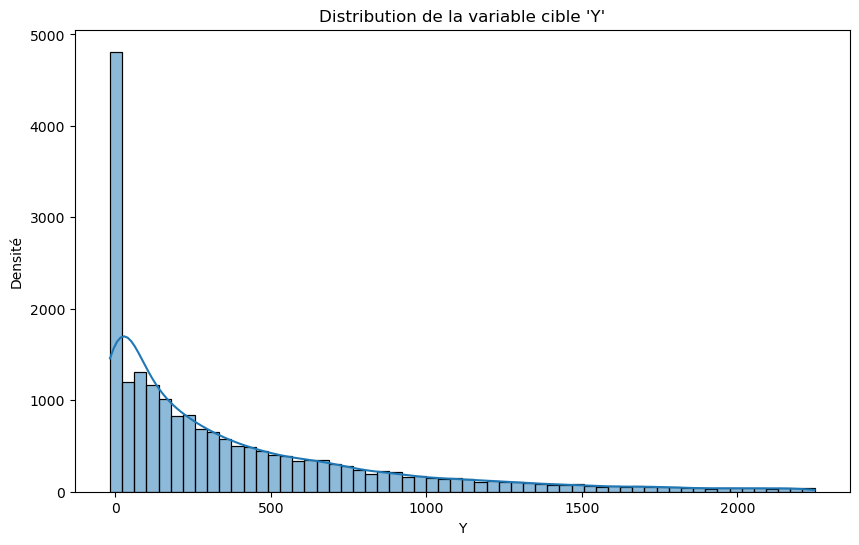

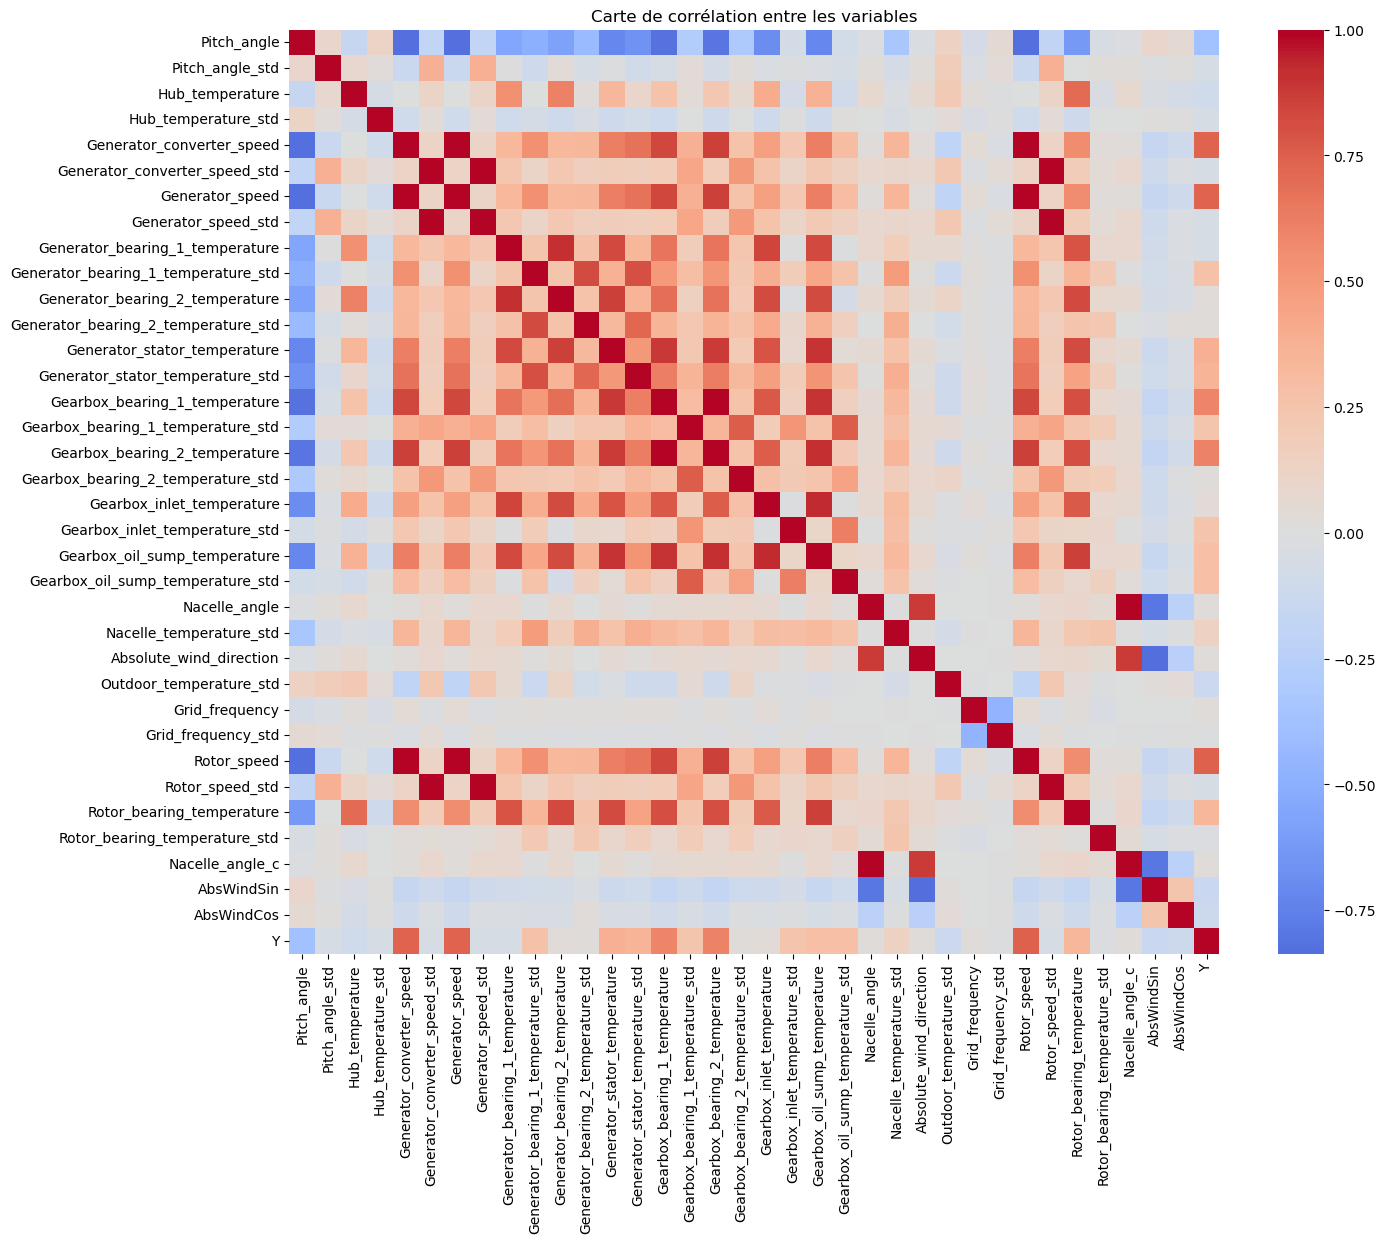

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation des distributions des variables pour explorer les données
donapp.describe()

# Visualiser la distribution de la variable cible 'Y' pour l'analyse initiale
plt.figure(figsize=(10, 6))
sns.histplot(donapp['Y'], kde=True)
plt.title("Distribution de la variable cible 'Y'")
plt.xlabel("Y")
plt.ylabel("Densité")
plt.show()

# Visualisation de la corrélation entre les variables pour identifier les plus pertinentes
plt.figure(figsize=(15, 12))
sns.heatmap(donapp.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Carte de corrélation entre les variables")
plt.show()

In [13]:
import pandas as pd
import numpy as np

# Calculer la matrice de corrélation
correlation_matrix = donapp.corr().abs()

# Fixer un seuil de corrélation pour identifier les corrélations fortes
threshold = 0.8

# Identifier les paires de caractéristiques fortement corrélées
high_corr_var = np.where(correlation_matrix > threshold)
high_corr_pairs = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y])
                   for x, y in zip(*high_corr_var) if x != y and x < y]

# Afficher les paires fortement corrélées
for var1, var2, corr_value in high_corr_pairs:
    print(f"Pair: {var1} - {var2} | Corrélation: {corr_value}")


Pair: Pitch_angle - Generator_converter_speed | Corrélation: 0.8254928993900449
Pair: Pitch_angle - Generator_speed | Corrélation: 0.825596413588926
Pair: Pitch_angle - Gearbox_bearing_1_temperature | Corrélation: 0.8212201137765457
Pair: Pitch_angle - Gearbox_bearing_2_temperature | Corrélation: 0.8054808258802626
Pair: Pitch_angle - Rotor_speed | Corrélation: 0.8249854735315252
Pair: Generator_converter_speed - Generator_speed | Corrélation: 0.9999960434535051
Pair: Generator_converter_speed - Gearbox_bearing_1_temperature | Corrélation: 0.8418527772859234
Pair: Generator_converter_speed - Gearbox_bearing_2_temperature | Corrélation: 0.8571461789464582
Pair: Generator_converter_speed - Rotor_speed | Corrélation: 0.999994709511637
Pair: Generator_converter_speed_std - Generator_speed_std | Corrélation: 0.9998943539163042
Pair: Generator_converter_speed_std - Rotor_speed_std | Corrélation: 0.9998457485065818
Pair: Generator_speed - Gearbox_bearing_1_temperature | Corrélation: 0.8419855

Pour cet exercice, nous utiliserons la Regression Ridge avec un alpha=1 , paramètre de contrôle de régularisation L2. ça nous permet de ne pas exclure de features tout en gérant les fortes corrélations.

### Note
>- Distribution de Y : Montre la répartition des valeurs, ce qui aide à anticiper la complexité de la prédiction.
>- Carte de corrélation : Permet d'identifier les variables potentiellement importantes pour prédire Y.
>- Nous utiliserons dans un premier temps la Regression Ridge avec un alpha=1 , paramètre de contrôle de régularisation L2. ça nous permet de ne pas exclure de features tout en gérant les fortes corrélations, puis nous passerons à une Random Forest, qui est plus robuste.

## Analyse de residus

/opt/mamba/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.367e+08, tolerance: 4.499e+05
  model = cd_fast.enet_coordinate_descent(
/opt/mamba/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.172e+08, tolerance: 4.499e+05
  model = cd_fast.enet_coordinate_descent(


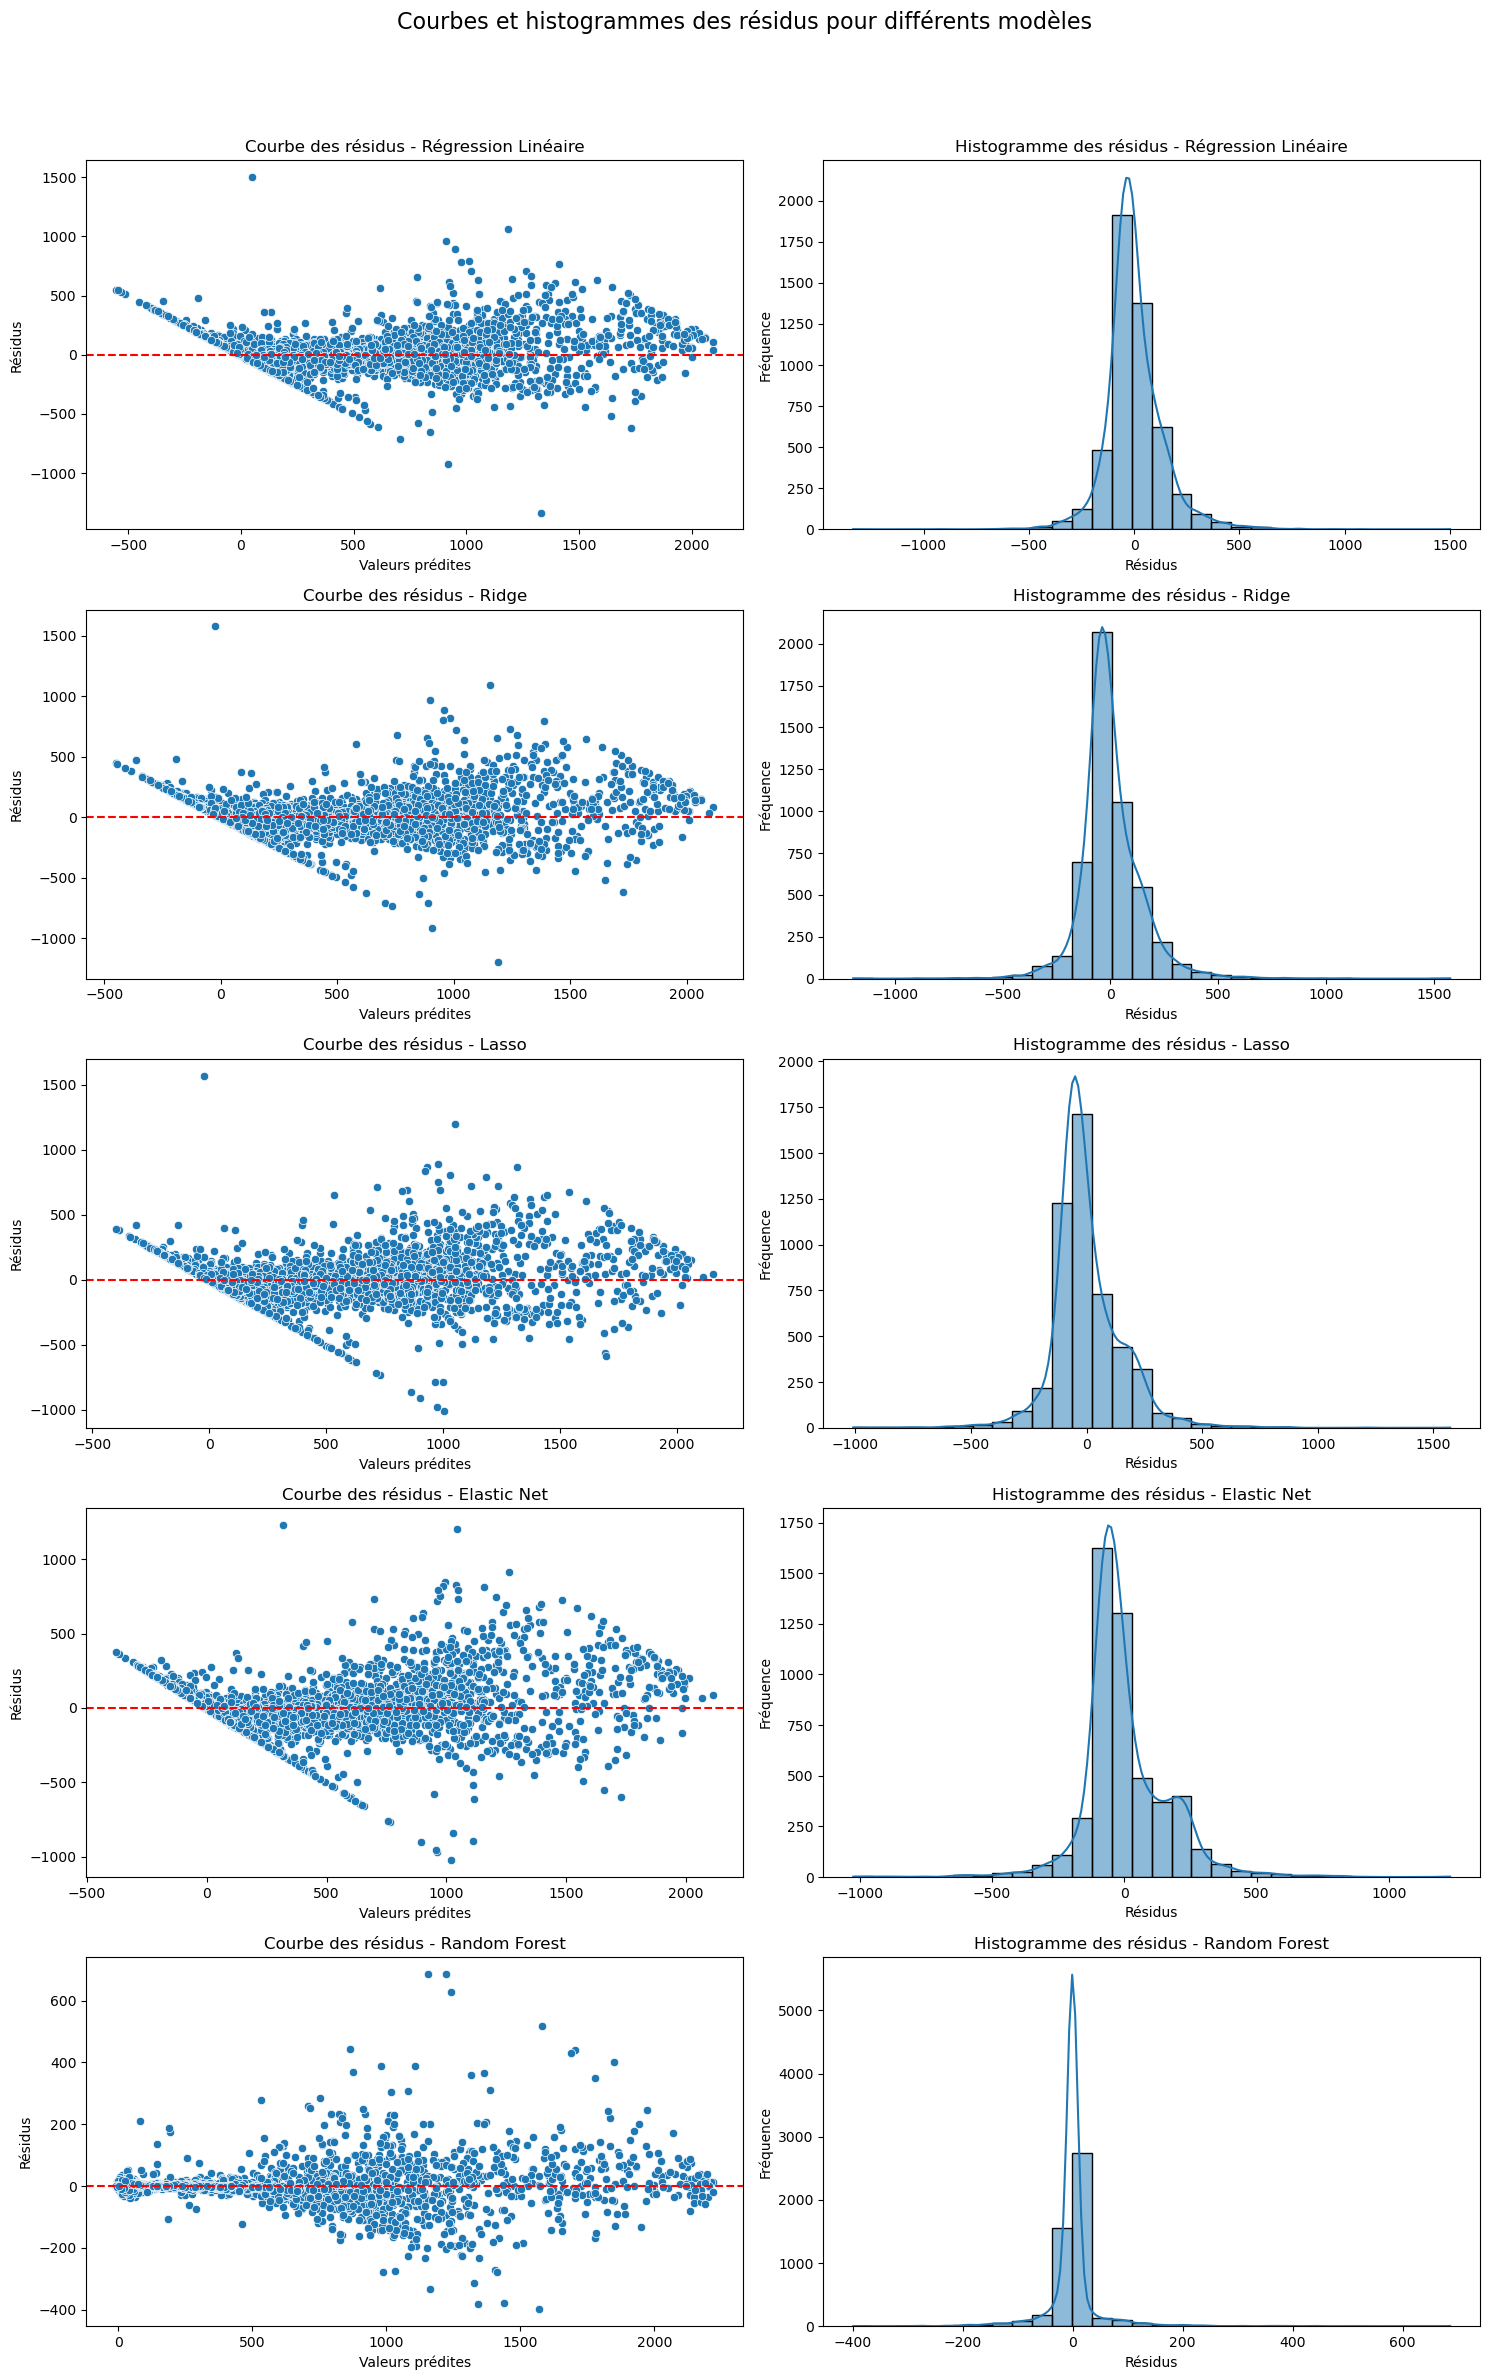

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Séparer les caractéristiques (X) et la cible (Y) pour le jeu de données d'apprentissage
X_train = donapp.drop(columns=['Y'])
y_train = donapp['Y']

# Pour les données de test
X_test = dontest.drop(columns=['Y'])
y_test = dontest['Y']


# Initialisation des modèles
models = {
    "Régression Linéaire": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
}

# Initialiser les sous-plots pour les visualisations (5 lignes, 2 colonnes)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
fig.suptitle("Courbes et histogrammes des résidus pour différents modèles", fontsize=16)

# Pour chaque modèle, calculer les résidus et créer les visualisations
for i, (name, model) in enumerate(models.items()):
    # Entraîner le modèle
    model.fit(X_train, y_train)
    
    # Calculer les prédictions et les résidus
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred  # Résidus
    
    # Tracer la courbe des résidus (à gauche) et l'histogramme des résidus (à droite)
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[i, 0])
    axes[i, 0].axhline(0, color='red', linestyle='--')
    axes[i, 0].set_title(f"Courbe des résidus - {name}")
    axes[i, 0].set_xlabel("Valeurs prédites")
    axes[i, 0].set_ylabel("Résidus")
    
    sns.histplot(residuals, bins=30, kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Histogramme des résidus - {name}")
    axes[i, 1].set_xlabel("Résidus")
    axes[i, 1].set_ylabel("Fréquence")

# Ajustement des espacements
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Note
> Random Forest semble de par ses équilibres et symtries capturer mieux la relation entre les variables indépendantes et dépendantes. 

## Ridge

### Modélisation et prédiction initiale

Nous choisissons dans un premier temps un modèle de régression linéaire Ridge de base pour effectuer une première estimation de la MSE sur les données de test.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso

# Séparer les caractéristiques (X) et la cible (Y) pour le jeu de données d'apprentissage
X_train = donapp.drop(columns=['Y'])
y_train = donapp['Y']

# Pour les données de test
X_test = dontest.drop(columns=['Y'])
y_test = dontest['Y']

# Paramètres des modèles Ridge et Lasso
alpha_value = 1.0  # Coefficient de régularisation

# Modèle de régression linéaire de base
model = Ridge(alpha=alpha_value)
model.fit(X_train, y_train)

# Prédictions et calcul de la MSE
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

19916.35326979767

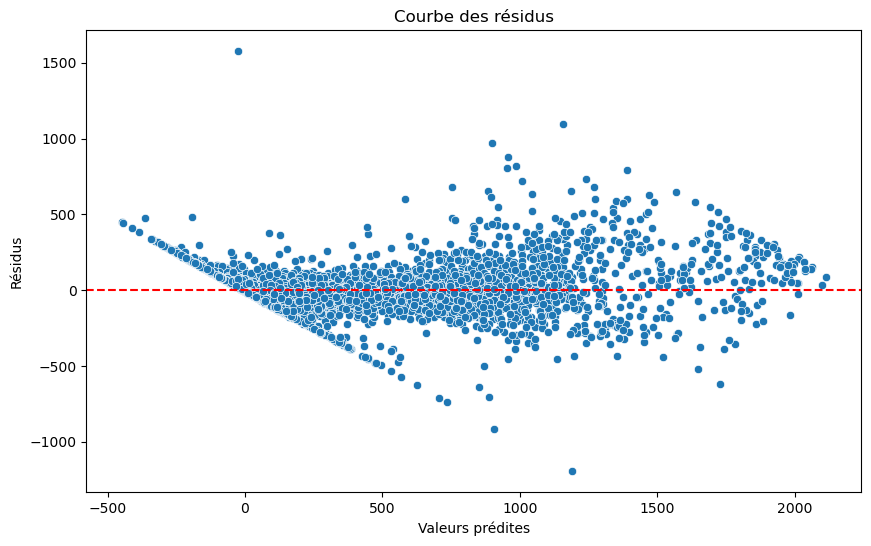

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul des résidus
y_pred = model.predict(X_test)  # Valeurs prédites
residuals = y_test - y_pred      # Résidus

# Tracer la courbe des résidus
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Courbe des résidus")
plt.show()


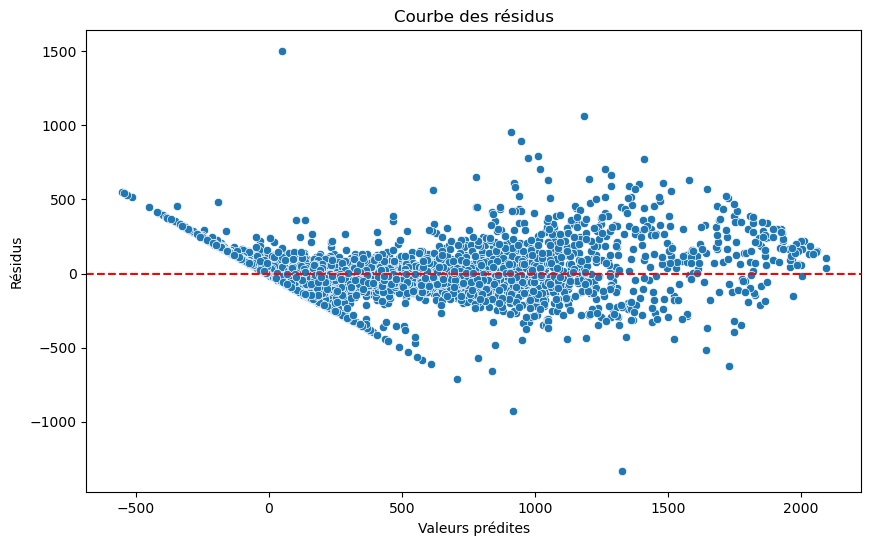

Mean Squared Error (MSE) : 19258.814114373432


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Entraîner un modèle de régression linéaire de base pour obtenir les prédictions
X_train = donapp.drop(columns=['Y'])
y_train = donapp['Y']
X_test = dontest.drop(columns=['Y'])
y_test = dontest['Y']

# Modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# Calculer les prédictions et les résidus
y_pred = model.predict(X_test)  # Valeurs prédites
residuals = y_test - y_pred      # Résidus

# Tracer la courbe des résidus
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Courbe des résidus")
plt.show()

# Calculer la MSE pour information
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) : {mse}")


/opt/mamba/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.172e+08, tolerance: 4.499e+05
  model = cd_fast.enet_coordinate_descent(


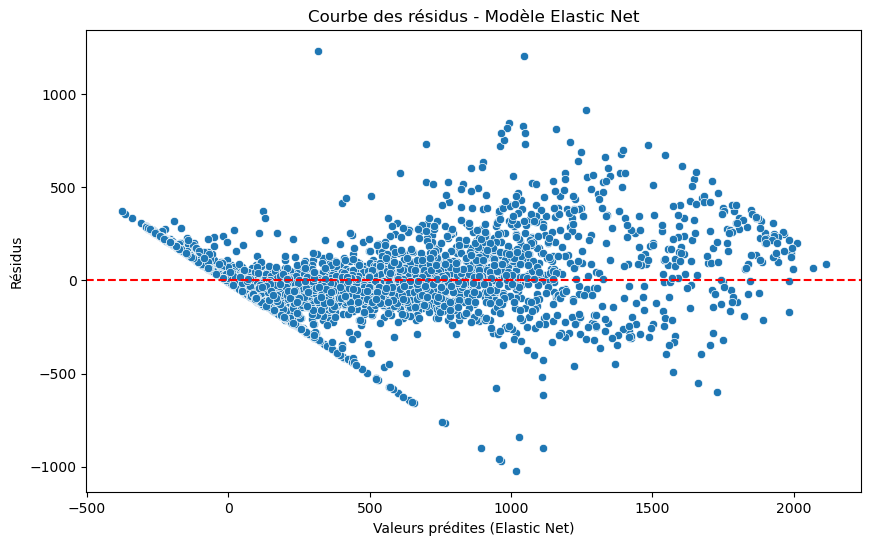

Mean Squared Error (MSE) avec Elastic Net : 25394.565423897675


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'Elastic Net
alpha_value = 1.0  # Coefficient de régularisation global
l1_ratio = 0.5     # Ratio entre L1 et L2 (0.5 signifie un équilibre entre Lasso et Ridge)

# Initialisation et entraînement du modèle Elastic Net
elastic_net_model = ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio, random_state=42)
elastic_net_model.fit(X_train, y_train)

# Calcul des prédictions et des résidus pour Elastic Net
en_pred = elastic_net_model.predict(X_test)
en_residuals = y_test - en_pred  # Résidus

# Tracer la courbe des résidus pour Elastic Net
plt.figure(figsize=(10, 6))
sns.scatterplot(x=en_pred, y=en_residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites (Elastic Net)")
plt.ylabel("Résidus")
plt.title("Courbe des résidus - Modèle Elastic Net")
plt.show()

# Calculer la MSE pour Elastic Net pour information
en_mse = mean_squared_error(y_test, en_pred)
print(f"Mean Squared Error (MSE) avec Elastic Net : {en_mse}")


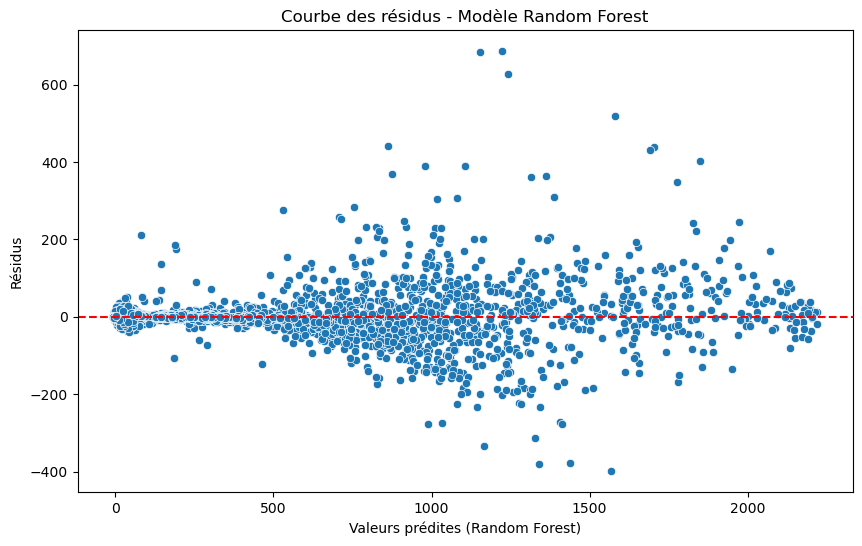

Mean Squared Error (MSE) avec Random Forest : 2424.599616500903


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Initialisation et entraînement du modèle Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,    # Nombre d'arbres dans la forêt
    max_depth=None,      # Profondeur maximale des arbres
    random_state=42,     # Pour des résultats reproductibles
    n_jobs=-1            # Utiliser tous les processeurs disponibles pour entraîner le modèle
)
rf_model.fit(X_train, y_train)

# Calcul des prédictions et des résidus pour Random Forest
rf_pred = rf_model.predict(X_test)
rf_residuals = y_test - rf_pred  # Résidus

# Tracer la courbe des résidus pour Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_pred, y=rf_residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites (Random Forest)")
plt.ylabel("Résidus")
plt.title("Courbe des résidus - Modèle Random Forest")
plt.show()

# Calculer la MSE pour Random Forest pour information
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Mean Squared Error (MSE) avec Random Forest : {rf_mse}")


/opt/mamba/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.172e+08, tolerance: 4.499e+05
  model = cd_fast.enet_coordinate_descent(


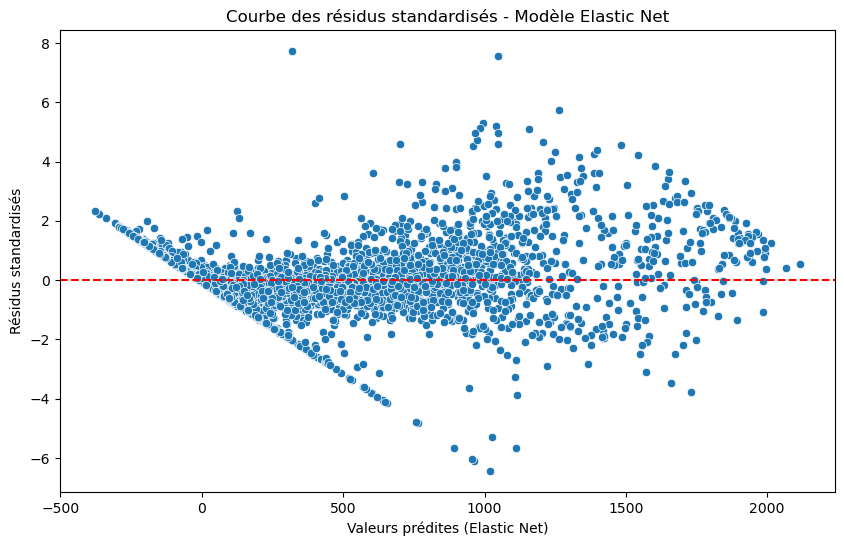

Mean Squared Error (MSE) avec Elastic Net : 25394.565423897675


In [ ]:
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Initialisation du modèle Elastic Net
alpha_value = 1.0  # Coefficient de régularisation global
l1_ratio = 0.5     # Équilibre entre L1 et L2

elastic_net_model = ElasticNet(alpha=alpha_value, l1_ratio=l1_ratio, random_state=42)
elastic_net_model.fit(X_train, y_train)

# Calcul des prédictions et des résidus pour Elastic Net
en_pred = elastic_net_model.predict(X_test)
en_residuals = y_test - en_pred  # Résidus

# Standardisation des résidus
std_en_residuals = (en_residuals - np.mean(en_residuals)) / np.std(en_residuals)

# Tracer la courbe des résidus standardisés pour Elastic Net
plt.figure(figsize=(10, 6))
sns.scatterplot(x=en_pred, y=std_en_residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites (Elastic Net)")
plt.ylabel("Résidus standardisés")
plt.title("Courbe des résidus standardisés - Modèle Elastic Net")
plt.show()

# Calculer la MSE pour référence
en_mse = mean_squared_error(y_test, en_pred)
print(f"Mean Squared Error (MSE) avec Elastic Net : {en_mse}")


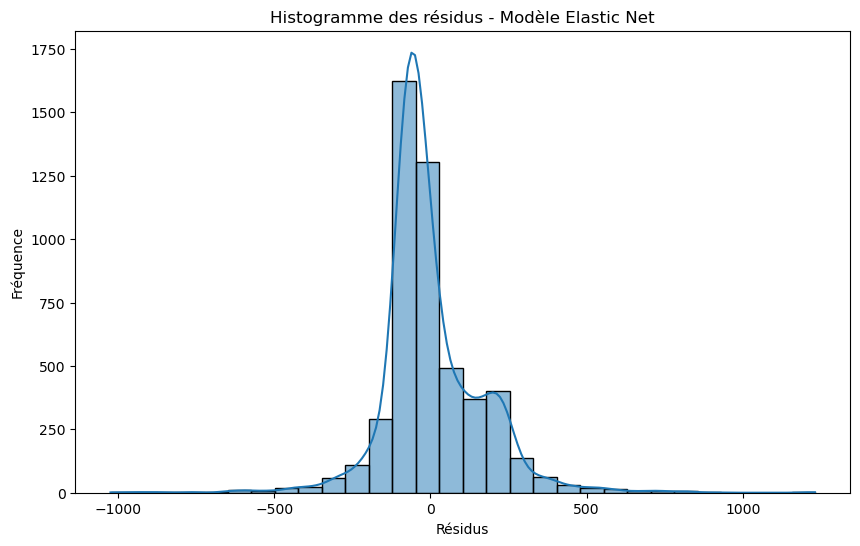

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tracer l'histogramme des résidus pour Elastic Net
plt.figure(figsize=(10, 6))
sns.histplot(en_residuals, bins=30, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Histogramme des résidus - Modèle Elastic Net")
plt.show()


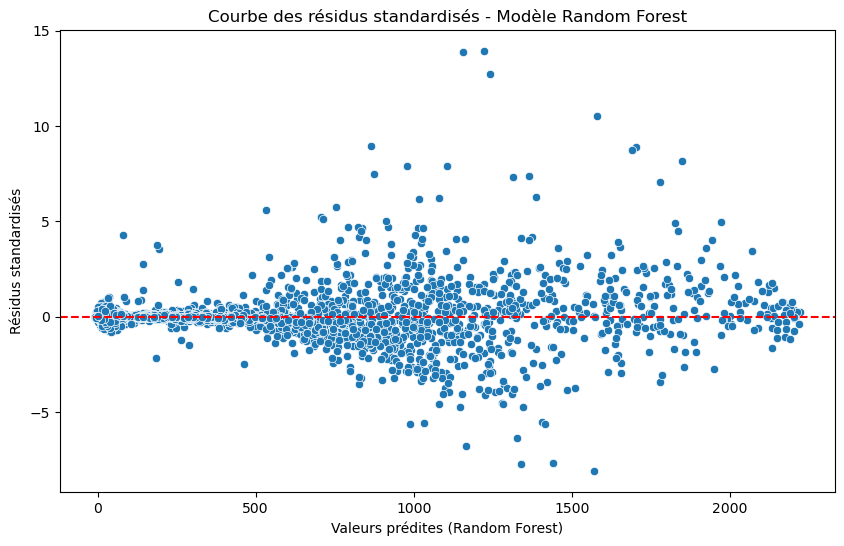

Mean Squared Error (MSE) avec Random Forest : 2424.599616500903


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Initialisation du modèle Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,    # Nombre d'arbres dans la forêt
    max_depth=None,      # Profondeur maximale des arbres
    random_state=42,     # Pour des résultats reproductibles
    n_jobs=-1            # Utiliser tous les processeurs disponibles pour entraîner le modèle
)
rf_model.fit(X_train, y_train)

# Prédictions et calcul des résidus pour Random Forest
rf_pred = rf_model.predict(X_test)
rf_residuals = y_test - rf_pred

# Standardisation des résidus
std_rf_residuals = (rf_residuals - np.mean(rf_residuals)) / np.std(rf_residuals)

# Tracer la courbe des résidus standardisés pour Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_pred, y=std_rf_residuals)
plt.axhline(0, color='red', linestyle='--')  # Ligne de référence à zéro
plt.xlabel("Valeurs prédites (Random Forest)")
plt.ylabel("Résidus standardisés")
plt.title("Courbe des résidus standardisés - Modèle Random Forest")
plt.show()

# Calculer la MSE pour référence
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Mean Squared Error (MSE) avec Random Forest : {rf_mse}")


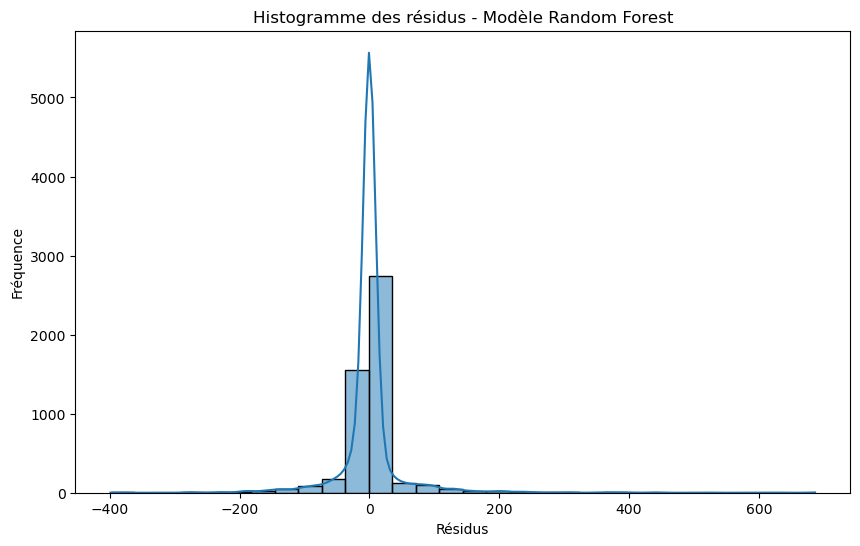

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tracer l'histogramme des résidus pour le modèle Random Forest
plt.figure(figsize=(10, 6))
sns.histplot(rf_residuals, bins=30, kde=True)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Histogramme des résidus - Modèle Random Forest")
plt.show()


### Note
>- La première estimation de la moyenne des erreurs de prévision au carré (MSE) pour le modèle de régression linéaire est de 19,916.35. Cette erreur nous donne une idée de la précision du modèle de base pour prédire la variable cible Y.
>- L'analyse résiduelle montre que la Random Forest de par son équilibre autours de l'axe des x (ou le fait qu'elle soit plus centrée et symétrique autour de zero dans l'histogramme des résidus ) cela indique que le modèle capture mieux la relation entre les variables indépendantes et dépendantes. 

### Classification en groupes et modélisation par groupe

#### Détérmination du nombre optimal de cluster par la Méthode du Coude.

La méthode du coude est utilisée pour déterminer le nombre optimal de clusters dans un ensemble de données.

1- Calculer l'inertie : Pour chaque nombre de clusters k, on calcule l'inertie, qui est la somme des distances au carré entre chaque point et son centre de cluster.

2- Tracer un graphe : On trace l'inertie en fonction du nombre de clusters.

3- Repérer le coude : Sur le graphe, on cherche le point où l'inertie cesse de diminuer de manière significative, formant un "coude".

Ce "coude" indique le nombre idéal de clusters, car il représente un bon équilibre entre compacité des clusters et complexité du modèle.

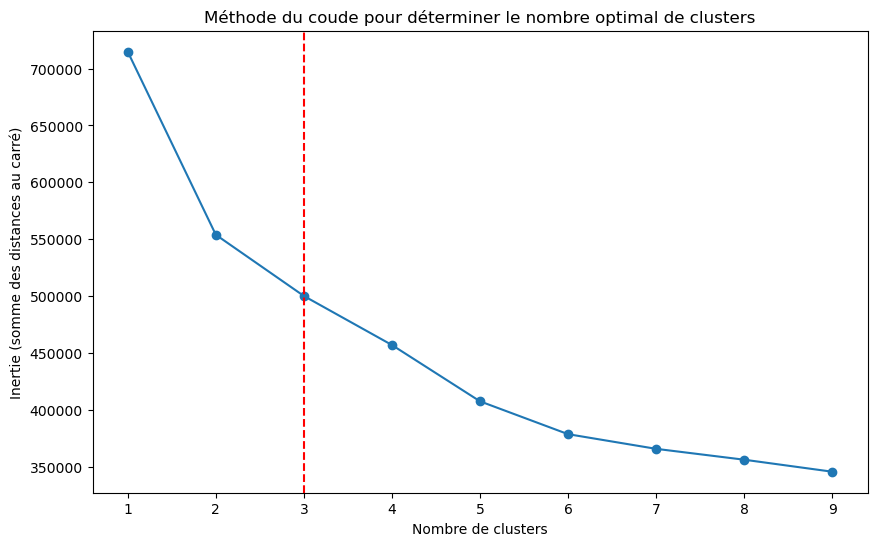

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Calculer l'inertie pour différents nombres de clusters
inertias = []
cluster_range = range(1, 10)  # On teste de 1 à 10 clusters

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Tracer le graphe de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertias, marker='o')
plt.axvline(x=3, color='red', linestyle='--')  # Ligne verticale sur 3 en rouge
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie (somme des distances au carré)")
plt.show()


## Classification en groupes et modélisation par groupe

Nous effectuons une classification en 3 groupes avec K-means, puis ajustons un modèle de régression pour chaque groupe afin d'améliorer les prédictions.

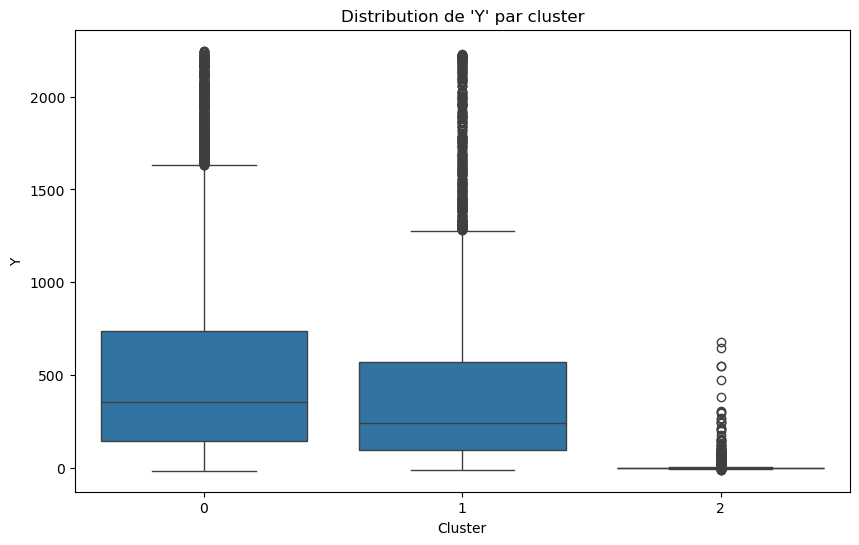

Cluster
0    11000
1     5539
2     3884
Name: count, dtype: int64

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardisation des données pour une meilleure performance de K-means
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Classification en 3 groupes avec K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

# Ajout des clusters aux données d'apprentissage
donapp['Cluster'] = clusters

# Visualisation de la distribution des clusters par rapport à la variable cible 'Y'
plt.figure(figsize=(10, 6))
sns.boxplot(x=donapp['Cluster'], y=donapp['Y'])
plt.title("Distribution de 'Y' par cluster")
plt.xlabel("Cluster")
plt.ylabel("Y")
plt.show()

# Vérifier la taille des clusters
donapp['Cluster'].value_counts()

### Note
>Nous avons effectué une classification des données en 3 groupes avec K-means. Voici les tailles de chaque cluster :

>- Cluster 1 : 11,000 observations
>- Cluster 2 : 5,539 observations
>- Cluster 0 : 3,884 observations
>Ces groupes montrent une distribution différente pour la variable cible Y, ce qui peut indiquer qu'un modèle spécifique pour chaque cluster pourrait améliorer les prédictions. Nous allons maintenant entraîner un modèle de régression pour chaque cluster et effectuer les prédictions pour le jeu de données de test. 

In [ ]:
from sklearn.metrics import mean_squared_error

# Préparer un dictionnaire pour stocker les modèles et erreurs pour chaque cluster
models = {}
mse_per_cluster = {}

# Appliquer le même clustering au jeu de données de test
X_test_scaled = scaler.transform(X_test)
test_clusters = kmeans.predict(X_test_scaled)

# Pour chaque cluster, entraîner un modèle et faire les prédictions
for cluster_id in donapp['Cluster'].unique():
    # Extraire les données du cluster
    cluster_data = donapp[donapp['Cluster'] == cluster_id]
    X_cluster = cluster_data.drop(columns=['Y', 'Cluster'])
    y_cluster = cluster_data['Y']

    # Entraîner un modèle de régression pour ce cluster
    alpha_value = 1.0  # Coefficient de régularisation
    model = Ridge(alpha=alpha_value)
    model.fit(X_cluster, y_cluster)

    # Stocker le modèle
    models[cluster_id] = model

    # Filtrer les données de test pour le cluster actuel
    X_test_cluster = X_test[test_clusters == cluster_id]
    y_test_cluster = y_test[test_clusters == cluster_id]

    # Faire les prédictions et calculer l'erreur pour le cluster
    y_pred_cluster = model.predict(X_test_cluster)
    mse_cluster = mean_squared_error(y_test_cluster, y_pred_cluster)

    # Stocker la MSE pour le cluster
    mse_per_cluster[cluster_id] = mse_cluster

mse_per_cluster

{2: 202.86673916254242, 0: 13480.861909831841, 1: 9674.444375019477}

### Note
>- Ces résultats montrent que l’approche par clusters a permis de réduire l’erreur de prévision, surtout pour le Cluster 2 (son MSE est 202.86). 

# Pour aller plus loin

## Random Forest

In [ ]:
# Charger les jeux de données
donapp = load_data(file_donapp)
dontest = load_data(file_dontest)

### Prédiction Initiale

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso

# Séparer les caractéristiques (X) et la cible (Y) pour le jeu de données d'apprentissage
X_train = donapp.drop(columns=['Y'])
y_train = donapp['Y']

# Pour les données de test
X_test = dontest.drop(columns=['Y'])
y_test = dontest['Y']
'''
# Paramètres des modèles Ridge et Lasso
alpha_value = 1.0  # Coefficient de régularisation
# Modèle de régression linéaire de base
model = Ridge(alpha=alpha_value)
'''
model = RandomForestRegressor(
    n_estimators=100,  # Nombre d'arbres dans la forêt
    max_depth=None,    # Profondeur maximale des arbres
    random_state=42,   # Pour des résultats reproductibles
    n_jobs=-1          # Utiliser tous les processeurs disponibles pour entraîner le modèle
)


model.fit(X_train, y_train)

# Prédictions et calcul de la MSE
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

2424.599616500903

### Classification en Groupe et Modélisation

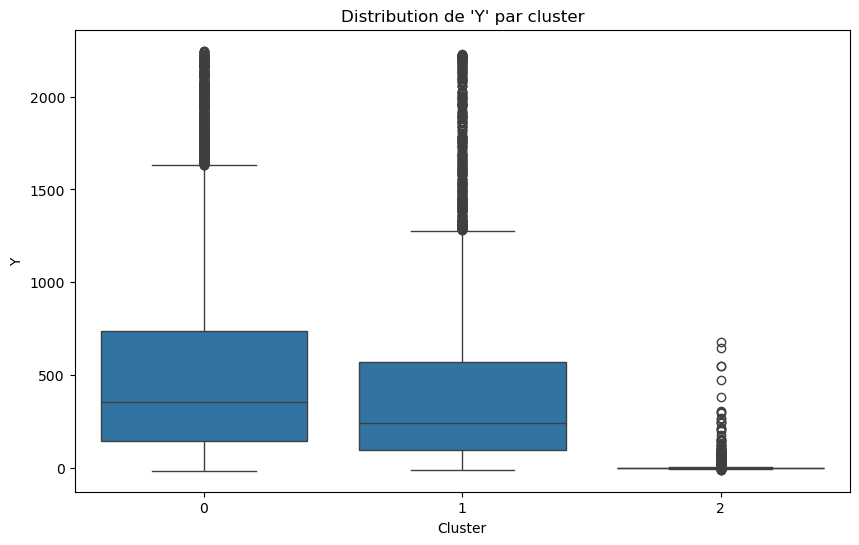

Cluster
0    11000
1     5539
2     3884
Name: count, dtype: int64

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardisation des données pour une meilleure performance de K-means
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Classification en 3 groupes avec K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

# Ajout des clusters aux données d'apprentissage
donapp['Cluster'] = clusters

# Visualisation de la distribution des clusters par rapport à la variable cible 'Y'
plt.figure(figsize=(10, 6))
sns.boxplot(x=donapp['Cluster'], y=donapp['Y'])
plt.title("Distribution de 'Y' par cluster")
plt.xlabel("Cluster")
plt.ylabel("Y")
plt.show()

# Vérifier la taille des clusters
donapp['Cluster'].value_counts()

In [ ]:
from sklearn.metrics import mean_squared_error

# Préparer un dictionnaire pour stocker les modèles et erreurs pour chaque cluster
models = {}
mse_per_cluster = {}

# Appliquer le même clustering au jeu de données de test
X_test_scaled = scaler.transform(X_test)
test_clusters = kmeans.predict(X_test_scaled)

# Pour chaque cluster, entraîner un modèle et faire les prédictions
for cluster_id in donapp['Cluster'].unique():
    # Extraire les données du cluster
    cluster_data = donapp[donapp['Cluster'] == cluster_id]
    X_cluster = cluster_data.drop(columns=['Y', 'Cluster'])
    y_cluster = cluster_data['Y']
    '''
    # Entraîner un modèle de régression pour ce cluster
    alpha_value = 1.0  # Coefficient de régularisation
    model = Ridge(alpha=alpha_value)
    '''   
    model = RandomForestRegressor(
    n_estimators=100,  # Nombre d'arbres dans la forêt
    max_depth=None,    # Profondeur maximale des arbres
    random_state=42,   # Pour des résultats reproductibles
    n_jobs=-1          # Utiliser tous les processeurs disponibles pour entraîner le modèle
    )
   
    model.fit(X_cluster, y_cluster)

    # Stocker le modèle
    models[cluster_id] = model

    # Filtrer les données de test pour le cluster actuel
    X_test_cluster = X_test[test_clusters == cluster_id]
    y_test_cluster = y_test[test_clusters == cluster_id]

    # Faire les prédictions et calculer l'erreur pour le cluster
    y_pred_cluster = model.predict(X_test_cluster)
    mse_cluster = mean_squared_error(y_test_cluster, y_pred_cluster)

    # Stocker la MSE pour le cluster
    mse_per_cluster[cluster_id] = mse_cluster

mse_per_cluster

{2: 28.159922300558204, 0: 3463.6530316730586, 1: 2434.732717475841}

### Note
Notre Random Forest à un meilleur MSE que Ridge dans tout les cas. En classification par groupes, le groupe 2 n'as plus qu'une MSE de 28. par contre, pour les deux autres groupes, la MSE reste du même ordre de grandeur, voir même est légèrement supérieure. Un tunning des hyper paramètres pourrait être intéressant. plus de groupes également (7 pour le 'deuxième coude' ?).

### Note
Dans notre cas, on observe donc que la classification aide les modele, en particulier ceux qui sont 'simple' à mieux prédire.